In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv
/kaggle/input/disasters-on-social-media/socialmedia-disaster-tweets-DFE.csv


 # **Import the data and get a feel for it**

In [3]:
train_sample = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
train_sample.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
train_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


## **Split the train dataset** 

In [5]:
y_train = train_sample.iloc[:,-1]
y_train

0       1
1       1
2       1
3       1
4       1
       ..
7608    1
7609    1
7610    1
7611    1
7612    1
Name: target, Length: 7613, dtype: int64

In [6]:
x_train = train_sample.iloc[:, :-1]
x_train

,id,keyword,location,text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or..."
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...
...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...


In [7]:
x_train.isna().sum()

id             0
keyword       61
location    2533
text           0
dtype: int64

In [8]:
x_train.fillna("0",inplace=True)

In [9]:
x_train

,id,keyword,location,text
0,1,0,0,Our Deeds are the Reason of this #earthquake M...
1,4,0,0,Forest fire near La Ronge Sask. Canada
2,5,0,0,All residents asked to 'shelter in place' are ...
3,6,0,0,"13,000 people receive #wildfires evacuation or..."
4,7,0,0,Just got sent this photo from Ruby #Alaska as ...
...,...,...,...,...
7608,10869,0,0,Two giant cranes holding a bridge collapse int...
7609,10870,0,0,@aria_ahrary @TheTawniest The out of control w...
7610,10871,0,0,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...
7611,10872,0,0,Police investigating after an e-bike collided ...


In [10]:
x_train.drop("id", axis=1, inplace=True)

In [11]:
x_train.isna().sum()

keyword     0
location    0
text        0
dtype: int64

## **Import the test dataset and exploring** 

In [12]:
test_sample = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
test_sample

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [13]:
x_test = test_sample.iloc[:, :]
x_test

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [14]:
x_test.isna().sum()

id             0
keyword       26
location    1105
text           0
dtype: int64

In [15]:
x_test.fillna("0", inplace=True)

In [16]:
x_test.isna().sum()

id          0
keyword     0
location    0
text        0
dtype: int64

In [17]:
x_test.drop("id", axis=1, inplace=True)

# **Data Exploration and Feature Engineering**
### Visally exploration of the features of the data 

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Target Values 

Text(0.5, 1.0, 'Distribution of target values')

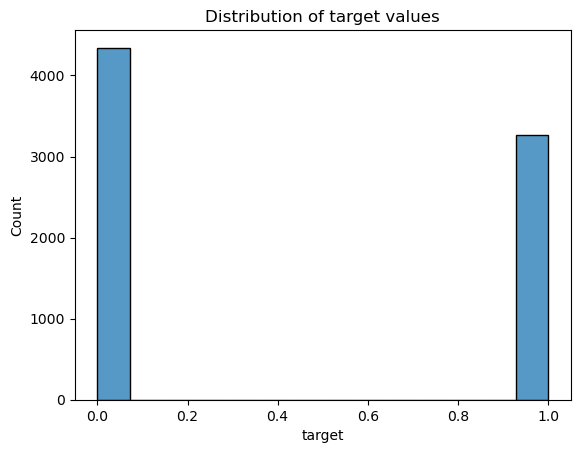

In [19]:
sns.histplot(x=train_sample["target"])
plt.title('Distribution of target values')

### Keyword 

In [20]:
keyword = train_sample.groupby("keyword")["target"].count()

keyword_df = pd.DataFrame(data={"keyword":keyword.index, "count":keyword.values}).sort_values(by=["count"],ascending=False)
keyword_df

,keyword,count
104,fatalities,45
63,deluge,42
8,armageddon,42
177,sinking,41
57,damage,41
...,...,...
115,forest%20fire,19
94,epicentre,12
194,threat,11
134,inundation,10


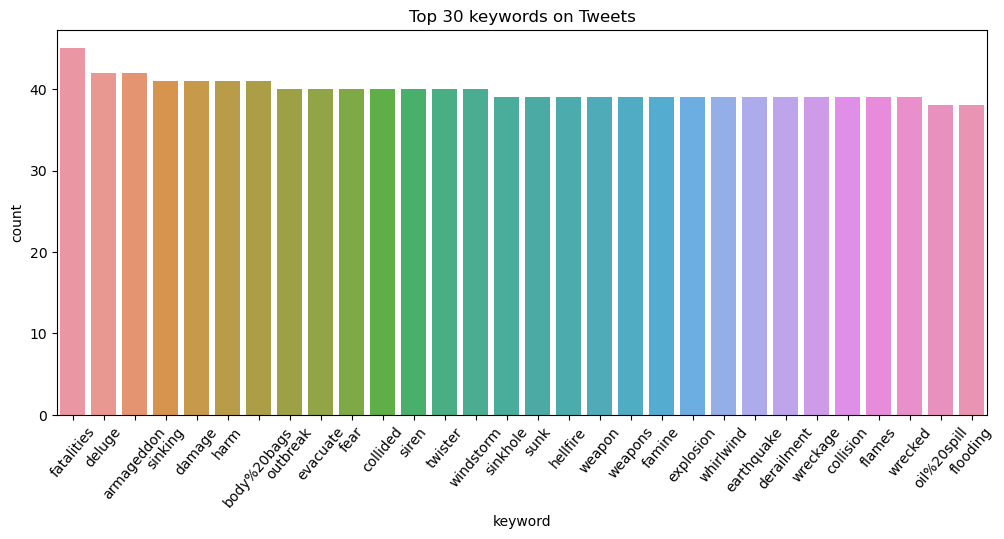

In [21]:
plt.figure(figsize=(12,5))
sns.barplot(data=keyword_df.head(30), x = 'keyword',y = 'count')
plt.xticks(rotation = 50)
plt.title('Top 30 keywords on Tweets');

### Location 

In [22]:
location = train_sample.groupby("location")["target"].count()

location_df = pd.DataFrame(data={"location":location.index, "count":location.values}).sort_values(by=["count"],ascending=False)
location_df

,location,count
2643,USA,104
1826,New York,71
2662,United States,50
1506,London,45
587,Canada,29
...,...,...
1198,Hueco Mundo,1
1199,"Hughes, AR",1
1200,"Huntington, WV",1
1201,"Huntley, IL",1


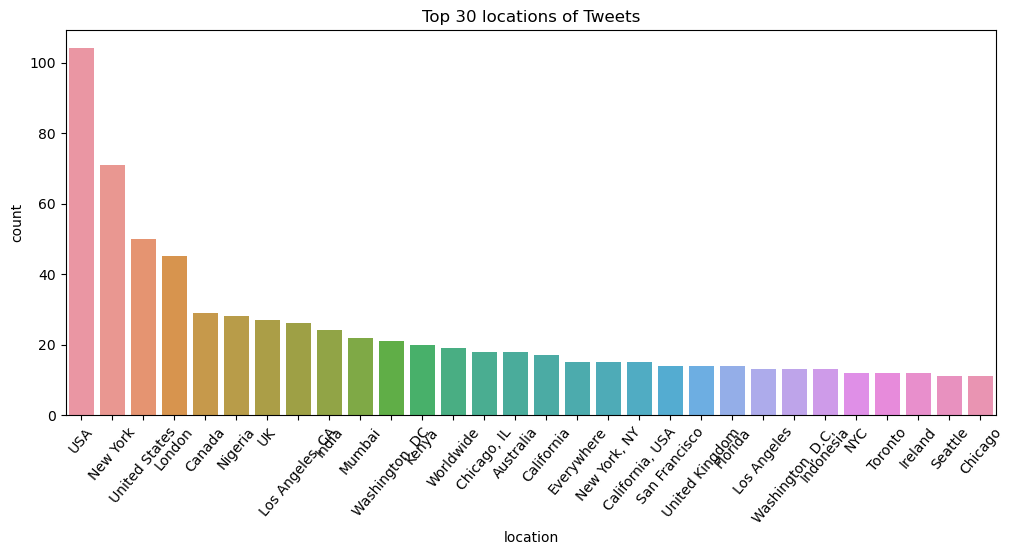

In [23]:
plt.figure(figsize=(12,5))

sns.barplot(data=location_df.head(30).iloc[:,:], x = 'location',y = 'count')
plt.xticks(rotation = 50)
plt.ylabel('count')
plt.title('Top 30 locations of Tweets');

### Analysis based on the length of the tweets

In [24]:
def get_sentence_lengths(df):
    df2 = pd.DataFrame(columns=["length"])
    i = 0
    for text in df["text"]:
        df2.loc[i,"length"] = len(text)
        i+=1
    return df2

def plot_sentence_lengths(df):
    lengths_df = get_sentence_lengths(df)
    bins = range(0,161,20)
    plt.hist(lengths_df["length"], bins=bins,alpha=0.3)
    plt.title("Distribution of sentence lengths")

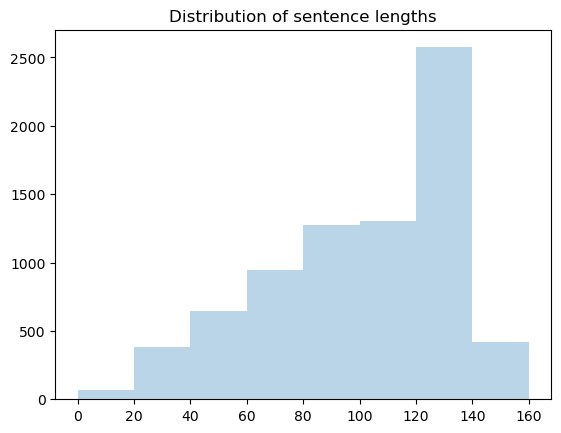

In [25]:
plot_sentence_lengths(train_sample)

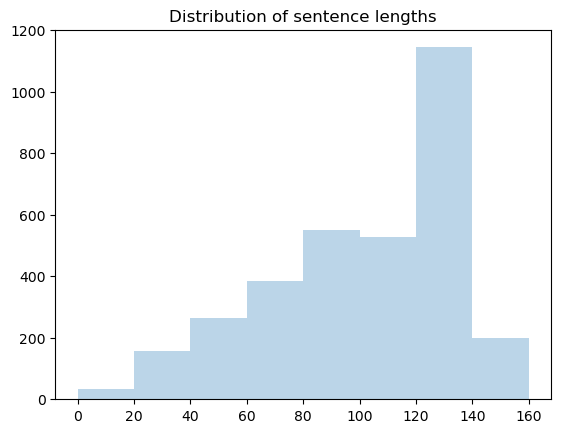

In [26]:
plot_sentence_lengths(test_sample)

### Checking how the length corresponds to the target-value 

In [27]:
sentence_length_df = get_sentence_lengths(train_sample)

merged_df = pd.concat([sentence_length_df, train_sample["target"]], axis=1)

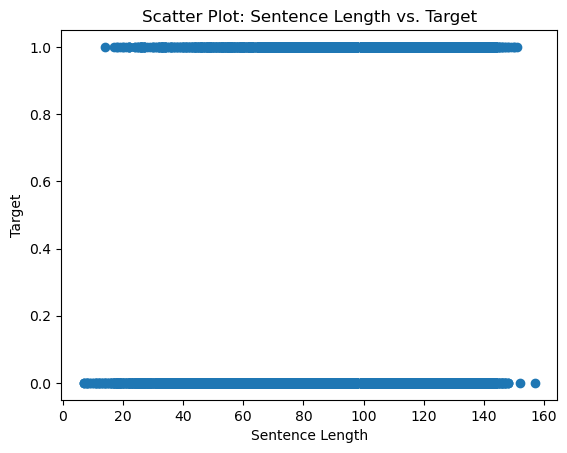

In [28]:
plt.scatter(merged_df["length"], merged_df["target"])

plt.xlabel('Sentence Length')
plt.ylabel('Target')
plt.title('Scatter Plot: Sentence Length vs. Target')

plt.show()

* ### After performing the analysis on the given dataset, we find that the number of data samples we have is just around 7000. 

* ### Aiming for a more robust training of our model, we will add an external dataset, i.e **disasters-on-social-media** , which is almost similar to our existing dataset. 

# **Adding an external dataset**
## Analyse the disaster on social media dataset

In [29]:
train2 = pd.read_csv('/kaggle/input/disasters-on-social-media/socialmedia-disaster-tweets-DFE.csv')
train2.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,choose_one,choose_one:confidence,choose_one_gold,keyword,location,text,tweetid,userid
0,778243823,True,golden,156,NaN,Relevant,1.0000,Relevant,NaN,NaN,Just happened a terrible car crash,1.0,NaN
1,778243824,True,golden,152,NaN,Relevant,1.0000,Relevant,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,13.0,NaN
2,778243825,True,golden,137,NaN,Relevant,1.0000,Relevant,NaN,NaN,"Heard about #earthquake is different cities, s...",14.0,NaN
3,778243826,True,golden,136,NaN,Relevant,0.9603,Relevant,NaN,NaN,"there is a forest fire at spot pond, geese are...",15.0,NaN
4,778243827,True,golden,138,NaN,Relevant,1.0000,Relevant,NaN,NaN,Forest fire near La Ronge Sask. Canada,16.0,NaN


In [30]:
train2s = train2[["keyword", "location", "text", "choose_one"]].copy()
train2s

,keyword,location,text,choose_one
0,NaN,NaN,Just happened a terrible car crash,Relevant
1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,Relevant
2,NaN,NaN,"Heard about #earthquake is different cities, s...",Relevant
3,NaN,NaN,"there is a forest fire at spot pond, geese are...",Relevant
4,NaN,NaN,Forest fire near La Ronge Sask. Canada,Relevant
...,...,...,...,...
10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,Relevant
10872,NaN,NaN,Police investigating after an e-bike collided ...,Relevant
10873,NaN,NaN,The Latest: More Homes Razed by Northern Calif...,Relevant
10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...,Relevant


In [31]:
train2s.isna().sum()

keyword         87
location      3638
text             0
choose_one       0
dtype: int64

In [32]:
train2s.fillna("0", inplace=True)
train2s.isna().sum()

keyword       0
location      0
text          0
choose_one    0
dtype: int64

In [33]:
train2s.rename(columns={"choose_one":"target"},inplace=True)
train2s.head()

,keyword,location,text,target
0,0,0,Just happened a terrible car crash,Relevant
1,0,0,Our Deeds are the Reason of this #earthquake M...,Relevant
2,0,0,"Heard about #earthquake is different cities, s...",Relevant
3,0,0,"there is a forest fire at spot pond, geese are...",Relevant
4,0,0,Forest fire near La Ronge Sask. Canada,Relevant


In [34]:
train2s["target"].unique()

array(['Relevant', 'Not Relevant', "Can't Decide"], dtype=object)

In [35]:
target_count = train2s["target"].value_counts()
target_count_df = pd.DataFrame(data={"target_category":target_count.index, "count":target_count.values})
target_count_df

,target_category,count
0,Not Relevant,6187
1,Relevant,4673
2,Can't Decide,16


Text(0.5, 1.0, 'Distribution of target values')

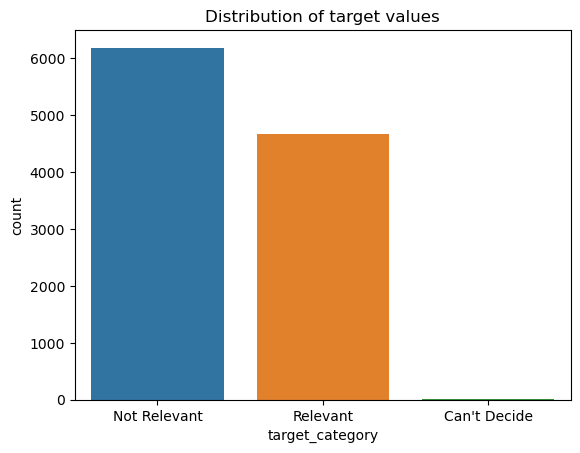

In [36]:
sns.barplot(data=target_count_df, x="target_category", y="count")
plt.title("Distribution of target values")

In [37]:
train2s["target"] = (train2s["target"] == "Relevant").astype("int")
train2s.head()

,keyword,location,text,target
0,0,0,Just happened a terrible car crash,1
1,0,0,Our Deeds are the Reason of this #earthquake M...,1
2,0,0,"Heard about #earthquake is different cities, s...",1
3,0,0,"there is a forest fire at spot pond, geese are...",1
4,0,0,Forest fire near La Ronge Sask. Canada,1


In [38]:
df = train2s["target"].value_counts()
df = pd.DataFrame({"target_value":df.index, "count":df.values})

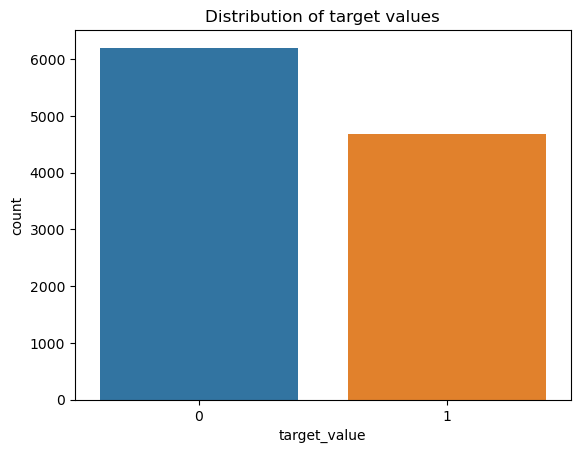

In [39]:
sns.barplot(data=df, x="target_value", y="count")
plt.title("Distribution of target values");

* ### We see that in both the datasets, the class 1 (real disaster ), is lesser in count. 

* ### For a more robust and balanced training, we will **upsample** the class 1 labels. 

* ### The reason I didn't want to downsample was that we are already running on a minimal dataset and I didn't want to still reduce the available count

## Merge Both the datasets 

In [40]:
train_dataset = pd.concat([train_sample, train2s])
train_dataset.head()

,id,keyword,location,text,target
0,1.0,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4.0,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5.0,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6.0,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7.0,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [41]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18489 entries, 0 to 10875
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        7613 non-null   float64
 1   keyword   18428 non-null  object 
 2   location  15956 non-null  object 
 3   text      18489 non-null  object 
 4   target    18489 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 866.7+ KB


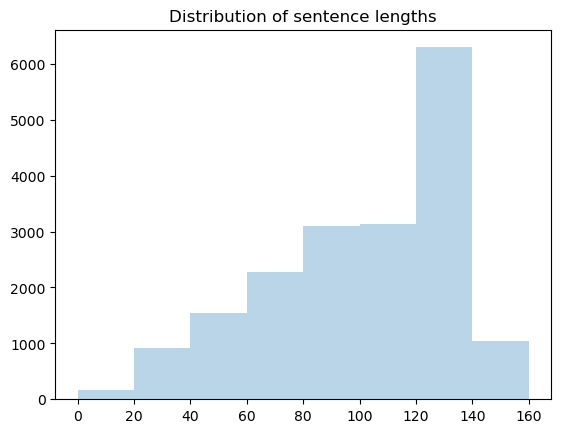

In [42]:
plot_sentence_lengths(train_dataset)

In [43]:
train_dataset['target'].value_counts()

0    10545
1     7944
Name: target, dtype: int64

In [44]:
df_0_class = train_dataset[train_dataset['target']==0]
df_1_class = train_dataset[train_dataset['target']==1]
df_1_class_upsampled = df_1_class.sample(df_0_class.shape[0], replace=True, random_state=42)
train_dataset = pd.concat([df_0_class, df_1_class_upsampled], axis=0)

In [45]:
train_dataset['target'].value_counts()

0    10545
1    10545
Name: target, dtype: int64

### So we clearly see here that the number of data samples for both the classes are equal now. 

In [46]:
SEED = 4243

### We will shuffle the dataset for both the datasets to get mingled equally and enusre that there is no bias based on the dataset

In [47]:
from sklearn.utils import shuffle

train_dataset = shuffle(train_dataset, random_state=SEED)
train_dataset = shuffle(train_dataset, random_state=int(SEED/2))
train_dataset.head()

,id,keyword,location,text,target
4702,NaN,epicentre,San Diego,@elisagxrcia I think of that every time I go t...,0
8238,NaN,riot,Mumbai,Stuart Broad Takes Eight Before Joe Root Runs ...,0
3456,NaN,derailed,"Edmonton, Alberta",Interesting to note: Metro train derailed in W...,1
442,NaN,apocalypse,0,Shadow boxing the apocalypse,1
1490,NaN,body%20bags,CLEVELAND,@ComplexMag he asking for a body bags @PUSHA_T,0


In [48]:
y_train = train_dataset.iloc[:, -1]
y_train

4702    0
8238    0
3456    1
442     1
1490    0
       ..
5088    0
8669    1
4889    1
7378    1
8016    1
Name: target, Length: 21090, dtype: int64

In [49]:
x_train = train_dataset.iloc[:, :-1]
x_train

,id,keyword,location,text
4702,NaN,epicentre,San Diego,@elisagxrcia I think of that every time I go t...
8238,NaN,riot,Mumbai,Stuart Broad Takes Eight Before Joe Root Runs ...
3456,NaN,derailed,"Edmonton, Alberta",Interesting to note: Metro train derailed in W...
442,NaN,apocalypse,0,Shadow boxing the apocalypse
1490,NaN,body%20bags,CLEVELAND,@ComplexMag he asking for a body bags @PUSHA_T
...,...,...,...,...
5088,NaN,famine,0,A grade in Black Horse Famine[MEGA]. Score 084...
8669,NaN,sinkhole,0,Sinkhole swallows Brooklyn intersection ‰ÛÒ vi...
4889,6961.0,massacre,NaN,@KabarMesir @badr58 \nNever dies a big Crime l...
7378,10561.0,windstorm,Puerto Rico,Reality Training: Train falls off elevated tra...


In [50]:
x_train.drop("id", axis=1, inplace=True)

* ### At this point, you can notice that there are inconsistencies like, there are both NaN and 0 values for the location and keyword column.  


* ### But we will not be cleaning these for now, as we will move forward and train the model only with the 'text' feature. 


* ### Also if you were wondering from where these inconsistencies have come, it is becase while merging we used train_sample and the train2s. 


* ### In train_sample we split it into x and y and we used only the x to clean the data. So we did 0 data-cleaning steps in train_sample, whereas the train2s consists of the cleaned data. 


* ### This is the reason for the inconsistency.

# **Dummy Classifier**

### Just out of mere curiosity checking the score of a dummy classifier with a cleaned data

In [51]:
from sklearn.dummy import DummyClassifier
?DummyClassifier

Init signature: DummyClassifier(*, strategy='prior', random_state=None, constant=None)
Docstring:     
DummyClassifier makes predictions that ignore the input features.

This classifier serves as a simple baseline to compare against other more
complex classifiers.

The specific behavior of the baseline is selected with the `strategy`
parameter.

All strategies make predictions that ignore the input feature values passed
as the `X` argument to `fit` and `predict`. The predictions, however,
typically depend on values observed in the `y` parameter passed to `fit`.

Note that the "stratified" and "uniform" strategies lead to
non-deterministic predictions that can be rendered deterministic by setting
the `random_state` parameter if needed. The other strategies are naturally
deterministic and, once fit, always return the same constant prediction
for any value of `X`.

Read more in the :ref:`User Guide <dummy_estimators>`.

.. versionadded:: 0.13

Parameters
----------
strategy : {"most_frequ

In [52]:
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(x_train, y_train)

DummyClassifier(strategy='stratified')

In [53]:
dummy_clf.predict(x_test)

array([1, 1, 0, ..., 0, 1, 0])

In [54]:
dummy_clf.score(x_train, y_train)

0.5027501185395922

In [55]:
y = y_train

# **Text Preprocessing Pipeline**

### Here we extensively use ntlk, for preprocessing. **nltk** is basically a natural language processing toolkit contains text processing libraries for tokenization. lemmatization, stemming etc

### In the preprocessing pipeline, the steps we will follow include :

1. ### Using a regular expression and matching the URLs and special characters

2. ### Tokenize the text using word_tokenize from nltk

3. ### Remove the stop_words from the texts

4. ### Then as a last stem using a Stemmer to stem the words into their base form.

In [56]:
import nltk
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import re

In [57]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [58]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

### Creating a reusable preprocessig function so that we can easily feed in the train data and the test data accordingly 

In [59]:
def preprocess_text(text):
    cleaned_text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    cleaned_text = re.sub(r'[^\w\s]', '', cleaned_text)

    tokens = nltk.word_tokenize(cleaned_text)
    
    filtered_tokens = [stemmer.stem(token) for token in tokens if token not in stop_words]
    return ' '.join(filtered_tokens)

In [60]:
x_train["text"] = x_train["text"].apply(preprocess_text)

In [61]:
x_train

,keyword,location,text
4702,epicentre,San Diego,elisagxrcia I think everi time I go epicentr haha
8238,riot,Mumbai,stuart broad take eight befor joe root run rio...
3456,derailed,"Edmonton, Alberta",interest note metro train derail washington mo...
442,apocalypse,0,shadow box apocalyps
1490,body%20bags,CLEVELAND,complexmag ask bodi bag pusha_t
...,...,...,...
5088,famine,0,A grade black hors faminemega score 0840728 dy...
8669,sinkhole,0,sinkhol swallow brooklyn intersect ÛÒ video
4889,massacre,NaN,kabarmesir badr58 never die big crime like rab...
7378,windstorm,Puerto Rico,realiti train train fall elev track windstorm


### Defining and using a Vectorizer for the the text column

In [62]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(x_train['text'])

In [63]:
print(tfidf_matrix)

  (0, 7249)	0.3934450219611339
  (0, 5685)	0.44462054903806275
  (0, 6934)	0.2619065834111317
  (0, 16176)	0.2721105793480019
  (0, 5814)	0.33674362432336014
  (0, 16056)	0.2972272107325938
  (0, 5516)	0.5505761281762835
  (1, 1921)	0.31945644898673464
  (1, 1175)	0.31945644898673464
  (1, 13554)	0.22816105281011043
  (1, 13802)	0.23407920158051318
  (1, 13698)	0.3212721000658756
  (1, 8737)	0.30726437637939763
  (1, 2297)	0.32317222981786364
  (1, 5470)	0.3460299738195818
  (1, 15658)	0.21308276513748226
  (1, 2892)	0.334279477661769
  (1, 15340)	0.3318032392933102
  (2, 158)	0.25924099210505547
  (2, 3765)	0.3175577167869399
  (2, 1142)	0.2279361936916254
  (2, 9640)	0.23817493387396493
  (2, 11741)	0.17097930672681133
  (2, 1681)	0.22487651925427588
  (2, 8337)	0.35118085461275195
  :	:
  (21087, 2065)	0.3419143661663057
  (21087, 8908)	0.3419143661663057
  (21087, 13474)	0.304251425956433
  (21087, 9784)	0.23618607774690206
  (21087, 4260)	0.2599503767089912
  (21087, 10201)	0.2326

* ### This is the preprocessing pipeline we define for the models to use. 


* ### But this pipeline has only a Vectorizer for now, as we have already preprocessed the data with tokenization, stemmer etc ...

In [64]:
categorical_features = ["text"]

preprocessor = ColumnTransformer(
    transformers=[
      ('tfidf', tfidf_vectorizer, 'text'),  
    ]
)

# **Model Building**

### As we have done the preprocessing and the feature engineering steps, now let us train various models with the preprocessed data we have, and the check how each model performs.

# **Logistic Regression**

In [65]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression()

clf_lg = Pipeline(
    steps = [("preprocessor", preprocessor), ("classifier", lg)]
)

clf_lg.fit(x_train, y)
print("model_score: %.3f" %clf_lg.score(x_train, y))

model_score: 0.923


# **Support Vector Machines**

In [66]:
from sklearn.svm import SVC

svc = SVC() 

clf_svc = Pipeline(
    steps = [("preprocessor", preprocessor), ("classifier", svc)]
)

clf_svc.fit(x_train, y)
print("model_score: %.3f" %clf_svc.score(x_train, y))

model_score: 0.981


# **Random Forest Classifier**

In [67]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

clf_rfc = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", rfc)]
)

clf_rfc.fit(x_train, y)
print('model score: %.3f' % clf_rfc.score(x_train, y))

model score: 0.986


# **Gradient Boosting Classifier**

In [68]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier()

clf_gbc = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", gbc)]
)

clf_gbc.fit(x_train, y)
print("model score: %.3f" % clf_gbc.score(x_train, y))

model score: 0.774


# **XB Boost Classifier**

In [69]:
import xgboost

xgb = xgboost.XGBClassifier()

clf_xgb = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", xgb)]
)

clf_xgb.fit(x_train, y)
print("model score: %.3f" % clf_xgb.score(x_train, y))

model score: 0.873


# **Bagging Classifier**

In [70]:
from sklearn.ensemble import BaggingClassifier

bgc = BaggingClassifier()

clf_bgc = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", bgc)]
)

clf_bgc.fit(x_train, y)
print('model score: %.3f' % clf_bgc.score(x_train, y))

model score: 0.983


# **Ada Boosting Classifier**

In [71]:
from sklearn.ensemble import AdaBoostClassifier

abc = AdaBoostClassifier()

clf_abc = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", abc)]
)

clf_abc.fit(x_train, y)
print('model score: %.3f' % clf_abc.score(x_train, y))

model score: 0.748


# **MLP Classifier**

In [72]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=1000)

clf_mlp = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", mlp)]
)

clf_mlp.fit(x_train, y)
print("model score: %.3f" % clf_mlp.score(x_train, y))

model score: 0.986


* ### After evaluating from the submissions we observe that the **Gradient Boosting Classifier** model generalizes well and performs better on the unseen data. 
* ### So now, let us perform hyperparameter tuning to increase the efficiency of Gradient Boosting Classifier

In [73]:
learning_rate = [0.02, 0.05, 0.15, 0.1, 0.2]
subsample = [0.5, 1]
n_estimators = [100, 500, 900, 1100, 1500]
min_samples_split = [2,5,10]
min_samples_leaf = [1,2,5]
max_depth = [2,3,5,10,15]
random_state = [42,101]
max_features = [1,2,3]
validation_fraction = [0.1, 0.2]
n_iter_no_change = [10,20]

hyperparameter_grid = {
    'classifier__subsample' : subsample,
    'classifier__n_estimators' : n_estimators,
    'classifier__min_samples_split' : min_samples_split,
    'classifier__min_samples_leaf' : min_samples_leaf,
    'classifier__max_depth' : max_depth,
    'classifier__random_state' : random_state,
    'classifier__learning_rate' : learning_rate,
    'classifier__validation_fraction' : validation_fraction,
    'classifier__n_iter_no_change' : n_iter_no_change
}

In [74]:
from sklearn.model_selection import RandomizedSearchCV

In [75]:
random_cv = RandomizedSearchCV(estimator=clf_gbc,
                               param_distributions=hyperparameter_grid,
                               cv=3,n_jobs=4,
                               verbose=1,
                               return_train_score = True,
                               random_state=42)

In [76]:
# random_cv.fit(x_train, y)

In [77]:
# random_cv.best_estimator_

In [78]:
clf_gbc_hyp = Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('tfidf', TfidfVectorizer(),
                                                  'text')])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.2, max_depth=10,
                                            min_samples_leaf=2,
                                            n_estimators=1100,
                                            n_iter_no_change=10,
                                            random_state=42, subsample=1))])

clf_gbc_hyp.fit(x_train, y)
print("model score: %.3f" % clf_gbc_hyp.score(x_train, y))

model score: 0.982


In [79]:
y_pred_gbc_hyp = clf_gbc_hyp.predict(x_test)
y_pred_gbc_hyp

array([1, 0, 1, ..., 0, 1, 0])

## **Using a transformer model like Bert with Neural Networks** 

* ### Here we use decide to use a pretrained bert model from tensorflow hub.

* ### tensorflow hub is a open repository and library for reusable machine learning code. We use the pre-trained bert model from the hub.

* ### https://www.tensorflow.org/hub/overview

In [80]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

* ### Also here in selecting the preprocesser and encoder layer, we use the documentation from tensorflow hub. 

* ### For the encoder, i use one of the 8 expert bert pretrained models that is BERT trained on Wikipedia and BooksCorpus and fine-tuned on SST-2. 

* ### https://tfhub.dev/google/experts/bert/wiki_books/sst2/2 

In [81]:
preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
encoder = hub.KerasLayer('https://tfhub.dev/google/experts/bert/wiki_books/sst2/2')

### This is the model we create, it has 8 layers, input layer, then the bert preprocessing and the bert encoding layer and then 2 dropout-dense layer pairs and then an output layer.

In [82]:
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text-layer')
preprocessed_text = preprocess(text_input)
outputs = encoder(preprocessed_text)
d_layer = tf.keras.layers.Dropout(0.1, name="dropout-layer1")(outputs['pooled_output'])
dense_layer1 = tf.keras.layers.Dense(256, activation='relu', name="dense-layer1")(d_layer)
dropout_layer2 = tf.keras.layers.Dropout(0.1, name="dropout-layer2")(dense_layer1)
dense_layer2 = tf.keras.layers.Dense(32, activation='relu', name="dense-layer2")(dropout_layer2)
output_layer = tf.keras.layers.Dense(1, activation='sigmoid', name="output")(dense_layer2)
model = tf.keras.Model(inputs=[text_input], outputs = [output_layer])

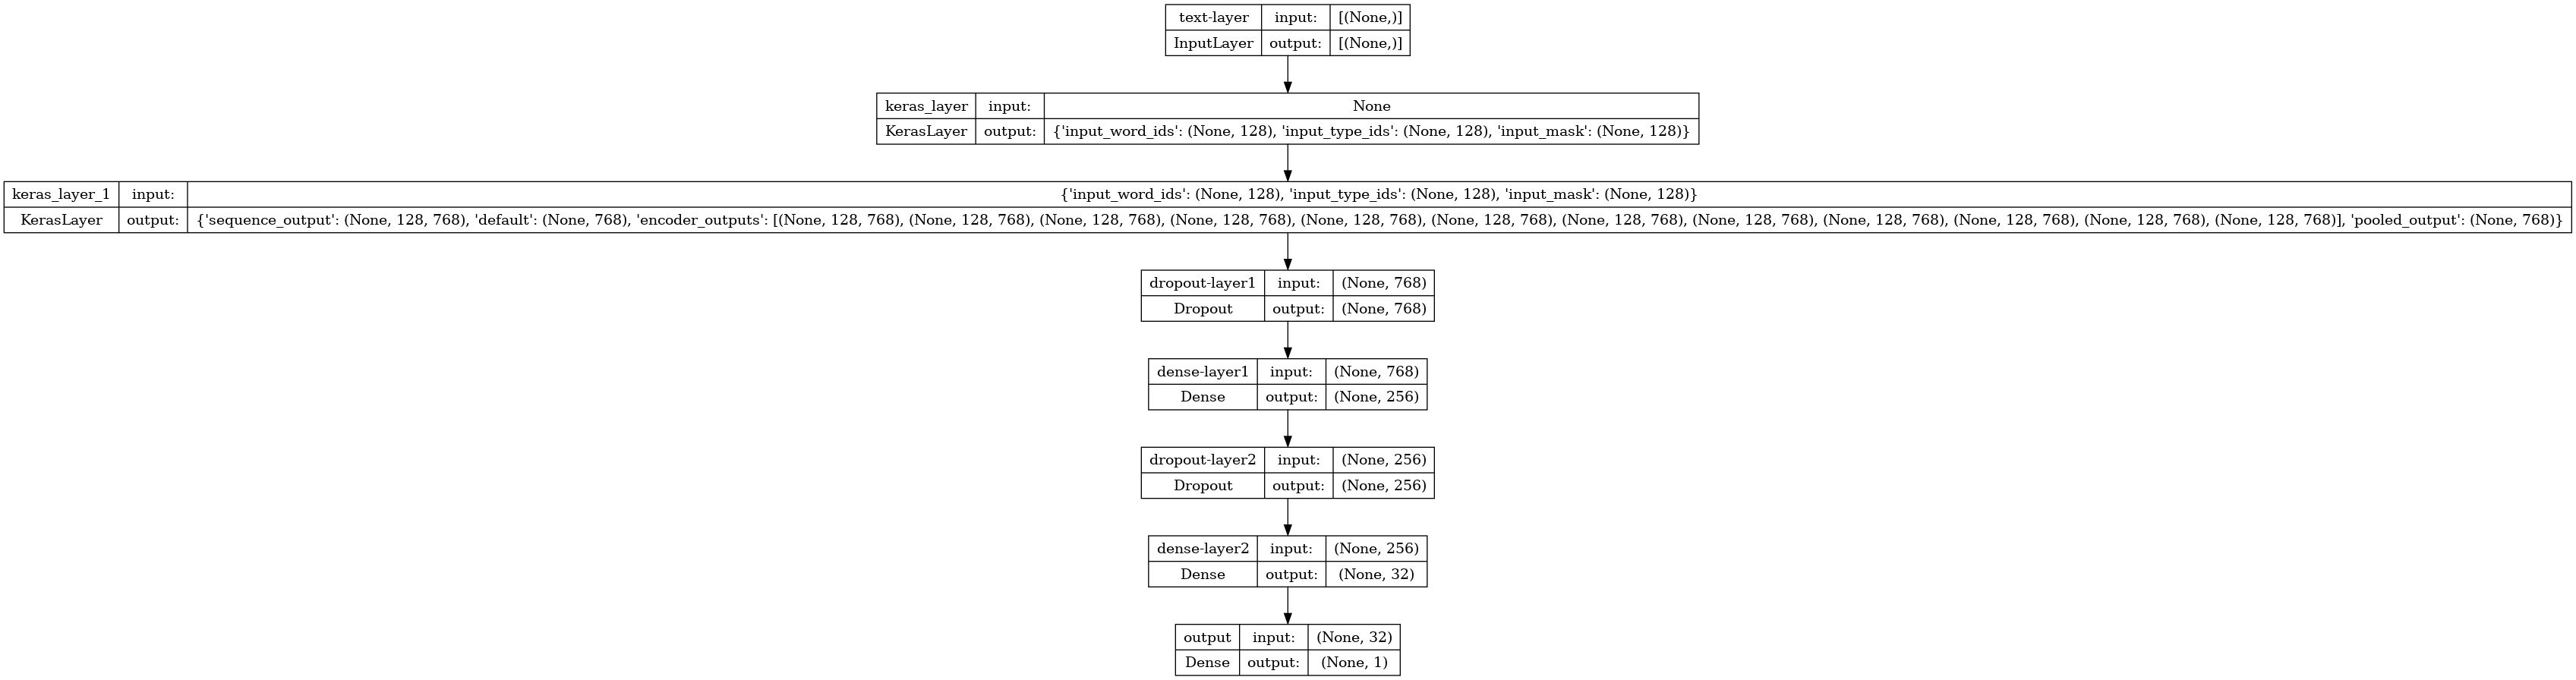

In [83]:
from keras.utils import plot_model
plot_model(model, to_file='model.png', show_shapes=True)

In [84]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text-layer (InputLayer)        [(None,)]            0           []                               
                                                                                                  
 keras_layer (KerasLayer)       {'input_word_ids':   0           ['text-layer[0][0]']             
                                (None, 128),                                                      
                                 'input_type_ids':                                                
                                (None, 128),                                                      
                                 'input_mask': (Non                                               
                                e, 128)}                                                      

In [85]:
m= [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall')
]
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=m)

In [87]:
model.fit(x_train['text'], y_train, epochs=10)

Epoch 1/10
660/660 [==============================] - 160s 220ms/step - loss: 0.5106 - accuracy: 0.7457 - precision: 0.7758 - recall: 0.6909
Epoch 2/10
660/660 [==============================] - 147s 223ms/step - loss: 0.4706 - accuracy: 0.7728 - precision: 0.8103 - recall: 0.7125
Epoch 3/10
660/660 [==============================] - 149s 225ms/step - loss: 0.4460 - accuracy: 0.7887 - precision: 0.8256 - recall: 0.7320
Epoch 4/10
660/660 [==============================] - 146s 221ms/step - loss: 0.4201 - accuracy: 0.8074 - precision: 0.8437 - recall: 0.7548
Epoch 5/10
660/660 [==============================] - 146s 221ms/step - loss: 0.3883 - accuracy: 0.8232 - precision: 0.8549 - recall: 0.7787
Epoch 6/10
660/660 [==============================] - 148s 225ms/step - loss: 0.3610 - accuracy: 0.8371 - precision: 0.8703 - recall: 0.7922
Epoch 7/10
660/660 [==============================] - 149s 226ms/step - loss: 0.3374 - accuracy: 0.8511 - precision: 0.8778 - recall: 0.8157
Epoch 8/10
66

In [98]:
y_pred = model.predict(x_train['text'])
y_pred = y_pred.flatten()
y_pred = np.where(y_pred > 0.5, 1, 0)

660/660 [==============================] - 144s 218ms/step


# **Model Evaluation and Selection**

In [99]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Let us do a comparative analysis of all the models we have used so far. 

In [100]:
model_names = ["lg", "svm", "rfc", "gbc", "xgb", "mlp", "bgc", "abc", "bert"]

clf_lg_pred = clf_lg.predict(x_train)
clf_svc_pred = clf_svc.predict(x_train)
clf_rfc_pred = clf_rfc.predict(x_train)
clf_gbc_pred = clf_gbc.predict(x_train)
clf_xgb_pred = clf_xgb.predict(x_train)
clf_mlp_pred = clf_mlp.predict(x_train)
clf_bgc_pred = clf_bgc.predict(x_train)
clf_abc_pred = clf_abc.predict(x_train)
clf_bert_pred = y_pred
true_labels = y_train

In [101]:
accuracy_scores = {}
precision_scores = {}
recall_scores = {}
f1_scores = {}

for model_name, predictions in zip(model_names, [clf_lg_pred, clf_svc_pred, clf_gbc_pred, clf_xgb_pred, clf_rfc_pred, clf_mlp_pred, clf_bgc_pred, clf_abc_pred, clf_bert_pred]):
    accuracy_scores[model_name] = accuracy_score(true_labels, predictions)
    precision_scores[model_name] = precision_score(true_labels, predictions)
    recall_scores[model_name] = recall_score(true_labels, predictions)
    f1_scores[model_name] = f1_score(true_labels, predictions)

In [102]:
data = {
    'Model': model_names,
    'Accuracy': list(accuracy_scores.values()),
    'Precision': list(precision_scores.values()),
    'Recall': list(recall_scores.values()),
    'F1 Score': list(f1_scores.values())
}
metrics_df = pd.DataFrame(data)

metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,lg,0.922949,0.944666,0.898530,0.921021
1,svm,0.980939,0.986195,0.975533,0.980835
2,rfc,0.773921,0.885596,0.629113,0.735640
3,gbc,0.872783,0.929242,0.807018,0.863828
4,xgb,0.986155,0.986986,0.985301,0.986143
5,mlp,0.985633,0.983844,0.987482,0.985660
6,bgc,0.982835,0.984305,0.981318,0.982809
7,abc,0.748032,0.830616,0.623139,0.712072
8,bert,0.920626,0.954970,0.882883,0.917513


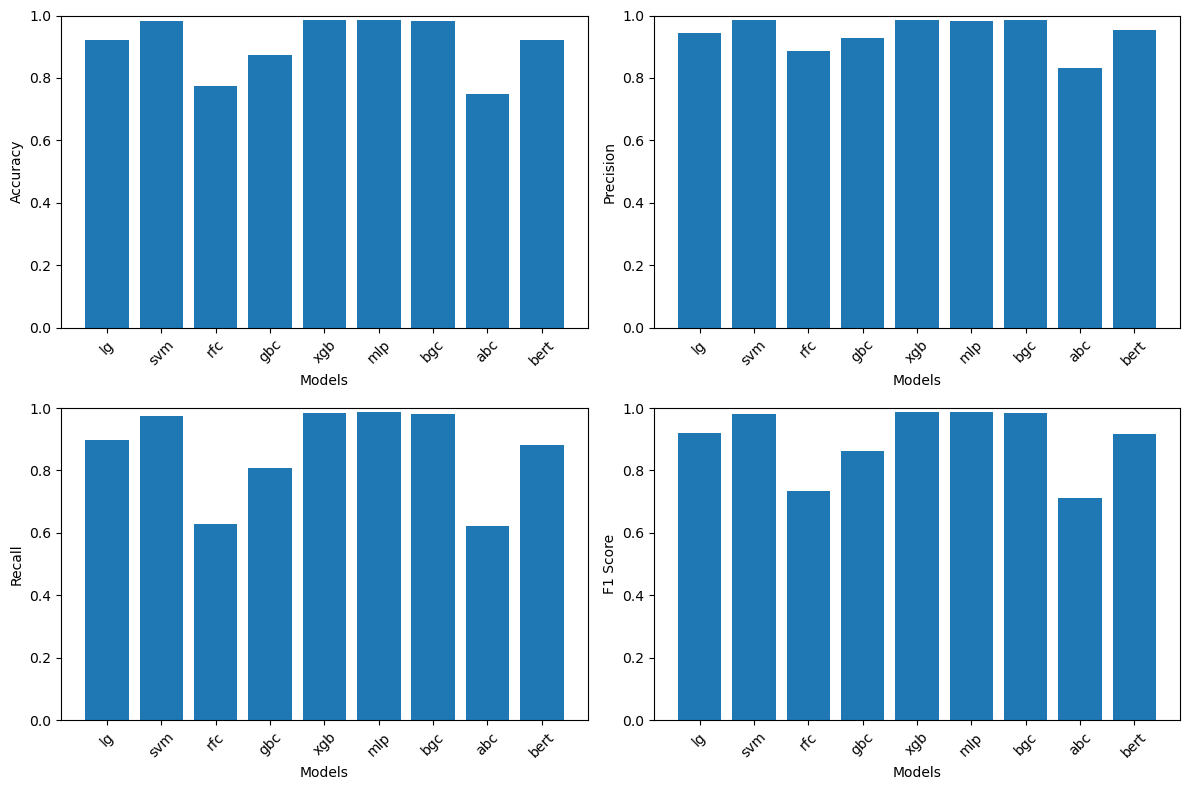

In [103]:
def plot_metric(metric_scores, metric_name):
    plt.bar(metric_scores.keys(), metric_scores.values())
    plt.xlabel('Models')
    plt.ylabel(metric_name)
    plt.ylim(0, 1)
    plt.xticks(rotation=45)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plot_metric(accuracy_scores, 'Accuracy')

plt.subplot(2, 2, 2)
plot_metric(precision_scores, 'Precision')

plt.subplot(2, 2, 3)
plot_metric(recall_scores, 'Recall')

plt.subplot(2, 2, 4)
plot_metric(f1_scores, 'F1 Score')

plt.tight_layout()

plt.show()

* ### So from the comparative analysis, we infer that the neural network model using bert transformer is the best in terms of generalising, accurary and then predicting the unseen data.  

* ### This model also performs better in the kaggle test data. 

# **Submission**

In [104]:
sample = pd.read_csv('/kaggle/input/nlp-getting-started/sample_submission.csv')

In [105]:
x_test['text'] = x_test["text"].apply(preprocess_text)

In [106]:
y_predicted = model.predict(x_test['text'])
y_predicted = y_predicted.flatten()
y_predicted = np.where(y_predicted > 0.5, 1, 0)

102/102 [==============================] - 22s 217ms/step


In [107]:
sample["target"] = y_predicted
sample.head()

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


In [108]:
sample.to_csv("submission.csv", index=False)

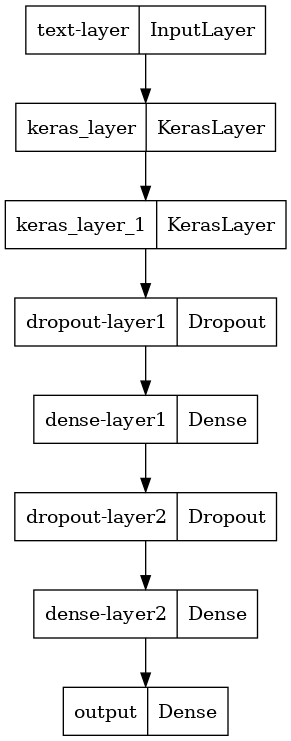

In [109]:
plot_model(model, to_file='model-best.png')